<a href="https://colab.research.google.com/github/nadalfinab/Data-Analyst-Portfolio/blob/main/HR_Employee_Attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Case Study: HR Employee Attrition Analysis
**Goal:** Support HR decision-making in talent retention strategies

**Description:** The analysis reveals that employee attrition is strongly influenced by factors such as job satisfaction, monthly income, and work-life balance. Employees with lower satisfaction levels and shorter tenure show a higher tendency to leave the company.

**Skills:** Data Cleaning, Data Preparation, Exploratory Data Analysis

**Results:** The analysis reveals that employee attrition is strongly influenced by factors such as job satisfaction, monthly income, and work-life balance. Employees with lower satisfaction levels and shorter tenure show a higher tendency to leave the company.

**Set Up**

Importing the necessary libraries I will use for this project

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

Reading in the data

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Big Data/cleansing HR Employee Attrition.csv', sep=",")
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
3,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
4,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0


looking at the data

In [5]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
3,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
4,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0


data cleaning

checking for misiing data

In [6]:
for col in df.columns:
    percent_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(percent_missing*100)))

Age - 0%
Attrition - 0%
BusinessTravel - 0%
DailyRate - 0%
Department - 0%
DistanceFromHome - 0%
Education - 0%
EducationField - 0%
EmployeeCount - 0%
EmployeeNumber - 0%
EnvironmentSatisfaction - 0%
Gender - 0%
HourlyRate - 0%
JobInvolvement - 0%
JobLevel - 0%
JobRole - 0%
JobSatisfaction - 0%
MaritalStatus - 0%
MonthlyIncome - 0%
MonthlyRate - 0%
NumCompaniesWorked - 0%
Over18 - 0%
OverTime - 0%
PercentSalaryHike - 0%
PerformanceRating - 0%
RelationshipSatisfaction - 0%
StandardHours - 0%
StockOptionLevel - 0%
TotalWorkingYears - 0%
TrainingTimesLastYear - 0%
WorkLifeBalance - 0%
YearsAtCompany - 0%
YearsInCurrentRole - 0%
YearsSinceLastPromotion - 0%
YearsWithCurrManager - 0%


removing null value from the data

In [7]:
df.dropna()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
3,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
4,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,47,No,Non-Travel,1169,Research & Development,14,4,Technical Degree,1,1934,...,3,80,1,16,4,4,8,7,1,7
959,28,Yes,Travel_Rarely,1404,Research & Development,17,3,Technical Degree,1,1960,...,1,80,1,6,2,2,4,1,0,3
960,40,No,Travel_Frequently,692,Research & Development,11,3,Technical Degree,1,1985,...,1,80,1,10,2,4,10,9,9,4
961,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,...,4,80,1,14,4,1,10,9,9,8


drop the duplicate

In [8]:
df.drop_duplicates()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
3,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
4,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,47,No,Non-Travel,1169,Research & Development,14,4,Technical Degree,1,1934,...,3,80,1,16,4,4,8,7,1,7
959,28,Yes,Travel_Rarely,1404,Research & Development,17,3,Technical Degree,1,1960,...,1,80,1,6,2,2,4,1,0,3
960,40,No,Travel_Frequently,692,Research & Development,11,3,Technical Degree,1,1985,...,1,80,1,10,2,4,10,9,9,4
961,56,Yes,Travel_Rarely,310,Research & Development,7,2,Technical Degree,1,2032,...,4,80,1,14,4,1,10,9,9,8


Checking the data type of the columns

In [9]:
print(df.dtypes)

Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWorkingYears   

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 963 entries, 0 to 962
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       963 non-null    int64 
 1   Attrition                 963 non-null    object
 2   BusinessTravel            963 non-null    object
 3   DailyRate                 963 non-null    int64 
 4   Department                963 non-null    object
 5   DistanceFromHome          963 non-null    int64 
 6   Education                 963 non-null    int64 
 7   EducationField            963 non-null    object
 8   EmployeeCount             963 non-null    int64 
 9   EmployeeNumber            963 non-null    int64 
 10  EnvironmentSatisfaction   963 non-null    int64 
 11  Gender                    963 non-null    object
 12  HourlyRate                963 non-null    int64 
 13  JobInvolvement            963 non-null    int64 
 14  JobLevel                  

In [11]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,963.000000,963.000000,963.000000,963.000000,963.0,963.000000,963.000000,963.000000,963.000000,963.000000,...,963.00000,963.0,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000,963.000000
mean,35.730010,799.662513,9.380062,2.899273,1.0,1012.143302,2.714434,66.197300,2.730010,1.753894,...,2.70405,80.0,0.813084,9.556594,2.803738,2.735202,6.218069,3.997923,1.881620,3.927310
std,8.603038,402.766454,8.213681,1.014054,0.0,607.984375,1.105867,20.002716,0.716455,0.767501,...,1.08412,0.0,0.876083,5.976015,1.322249,0.703035,4.775436,3.354644,2.799336,3.358192
min,18.000000,103.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.00000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,466.500000,2.000000,2.000000,1.0,464.500000,2.000000,48.000000,2.000000,1.000000,...,2.00000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,35.000000,806.000000,7.000000,3.000000,1.0,1009.000000,3.000000,67.000000,3.000000,2.000000,...,3.00000,80.0,1.000000,9.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,41.000000,1146.500000,15.000000,4.000000,1.0,1548.500000,4.000000,83.000000,3.000000,2.000000,...,4.00000,80.0,1.000000,12.000000,3.000000,3.000000,9.000000,7.000000,2.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,4.000000,...,4.00000,80.0,3.000000,38.000000,6.000000,4.000000,37.000000,17.000000,15.000000,17.000000


calculates the total number of missing or null values

In [13]:
df.isna().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


swap the rows and columns of the descriptive statistics summary generated by the describe

In [14]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,963.0,35.730010,8.603038,18.0,30.0,35.0,41.0,60.0
DailyRate,963.0,799.662513,402.766454,103.0,466.5,806.0,1146.5,1499.0
DistanceFromHome,963.0,9.380062,8.213681,1.0,2.0,7.0,15.0,29.0
Education,963.0,2.899273,1.014054,1.0,2.0,3.0,4.0,5.0
EmployeeCount,963.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,963.0,1012.143302,607.984375,1.0,464.5,1009.0,1548.5,2068.0
EnvironmentSatisfaction,963.0,2.714434,1.105867,1.0,2.0,3.0,4.0,4.0
HourlyRate,963.0,66.197300,20.002716,30.0,48.0,67.0,83.0,100.0
JobInvolvement,963.0,2.730010,0.716455,1.0,2.0,3.0,3.0,4.0
JobLevel,963.0,1.753894,0.767501,1.0,1.0,2.0,2.0,4.0


change categorical data to number for analysis machine learning

In [17]:
# Import Module
from sklearn.preprocessing import OneHotEncoder

# Encoder
encoder = OneHotEncoder(sparse_output=False)

# Encode Categorical Data
df_encoded = pd.DataFrame(encoder.fit_transform(df[[ 'BusinessTravel', 'Department', 'EducationField','Gender','JobRole','MaritalStatus','Over18','OverTime']]))
df_encoded.columns = encoder.get_feature_names_out(['BusinessTravel', 'Department', 'EducationField','Gender','JobRole','MaritalStatus','Over18','OverTime'])

# Replace Categotical Data with Encoded Data
df.drop(['BusinessTravel', 'Department', 'EducationField','Gender','JobRole','MaritalStatus','Over18','OverTime'] ,axis=1, inplace=True)
df_encoded= pd.concat([df, df_encoded], axis=1)

# Show Encoded Dataframe
df_encoded

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,JobRole_Laboratory Technician,JobRole_Manufacturing Director,JobRole_Research Scientist,JobRole_Sales Executive,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,41,Yes,1102,1,2,1,1,2,94,3,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
1,49,No,279,8,1,1,2,3,61,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,33,No,1392,3,4,1,5,4,56,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,32,No,1005,2,2,1,8,4,79,3,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,30,No,1358,24,1,1,11,4,67,3,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,47,No,1169,14,4,1,1934,3,64,3,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
959,28,Yes,1404,17,3,1,1960,3,32,2,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
960,40,No,692,11,3,1,1985,4,73,3,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
961,56,Yes,310,7,2,1,2032,4,72,3,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [18]:
# Select Features
feature = df_encoded.drop(['JobSatisfaction', 'MonthlyIncome', 'Attrition'], axis=1)
feature

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manufacturing Director,JobRole_Research Scientist,JobRole_Sales Executive,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
0,41,1102,1,2,1,1,2,94,3,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
1,49,279,8,1,1,2,3,61,2,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
2,33,1392,3,4,1,5,4,56,3,1,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0
3,32,1005,2,2,1,8,4,79,3,1,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
4,30,1358,24,1,1,11,4,67,3,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,47,1169,14,4,1,1934,3,64,3,2,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
959,28,1404,17,3,1,1960,3,32,2,1,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
960,40,692,11,3,1,1985,4,73,3,2,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
961,56,310,7,2,1,2032,4,72,3,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0


In [19]:
feature.isnull().sum()

feature.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,963.0,35.730010,8.603038,18.0,30.0,35.0,41.0,60.0
DailyRate,963.0,799.662513,402.766454,103.0,466.5,806.0,1146.5,1499.0
DistanceFromHome,963.0,9.380062,8.213681,1.0,2.0,7.0,15.0,29.0
Education,963.0,2.899273,1.014054,1.0,2.0,3.0,4.0,5.0
EmployeeCount,963.0,1.000000,0.000000,1.0,1.0,1.0,1.0,1.0
EmployeeNumber,963.0,1012.143302,607.984375,1.0,464.5,1009.0,1548.5,2068.0
EnvironmentSatisfaction,963.0,2.714434,1.105867,1.0,2.0,3.0,4.0,4.0
HourlyRate,963.0,66.197300,20.002716,30.0,48.0,67.0,83.0,100.0
JobInvolvement,963.0,2.730010,0.716455,1.0,2.0,3.0,3.0,4.0
JobLevel,963.0,1.753894,0.767501,1.0,1.0,2.0,2.0,4.0


In [20]:
# Select Target
target = df_encoded['Attrition']
target

,Attrition
0,Yes
1,No
2,No
3,No
4,No
...,...
958,No
959,Yes
960,No
961,Yes


In [21]:
# Set Training and Testing Data (70:30)
from sklearn.model_selection import train_test_split, cross_val_score
X_train, X_test, y_train, y_test  = train_test_split(feature , target, shuffle = True, test_size=0.3, random_state=1)

# Show the Training and Testing Data
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(674, 45)
(289, 45)
(674,)
(289,)


In [22]:
X_test

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manufacturing Director,JobRole_Research Scientist,JobRole_Sales Executive,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,Over18_Y,OverTime_No,OverTime_Yes
241,36,217,18,4,1,1133,1,78,3,2,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
854,31,976,3,2,1,1948,3,48,3,1,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
527,49,1313,11,4,1,1757,4,80,3,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
906,58,289,2,3,1,977,4,51,3,1,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0
345,35,1349,7,2,1,1601,3,63,2,1,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
134,41,267,10,2,1,599,4,56,3,2,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0
770,43,930,6,3,1,1402,1,73,2,2,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0
320,29,1246,19,3,1,1497,3,77,2,2,...,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
57,30,1339,5,3,1,228,2,41,3,3,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0


In [23]:
y_test

,Attrition
241,No
854,No
527,No
906,Yes
345,No
...,...
134,No
770,No
320,No
57,No


In [24]:
# Import Module
from sklearn import tree

# Modeling Decision Tree
dtc = tree.DecisionTreeClassifier(min_impurity_decrease=0.01)
dtc.fit(X_train, y_train)

# Predict to Test Data
y_pred_dtc = dtc.predict(X_test)

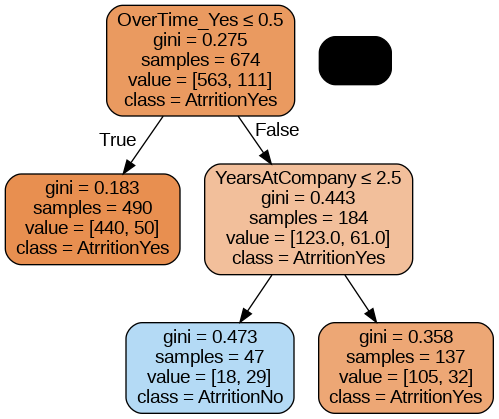

In [25]:
# Visualize Tree

from six import StringIO
from IPython.display import Image
from sklearn.tree import export_graphviz
import pydotplus

dot_data = StringIO()
export_graphviz(dtc, out_file=dot_data,
                filled=True, rounded=True,
                special_characters=True,
                class_names=['AtrritionYes', 'AtrritionNo'],
                feature_names=['Age',	'DailyRate',	'DistanceFromHome', 'EmployeeCount',	'EmployeeNumber', 'EnvirontmenSatisfaction',	'Hourlyrate',	'JobInvolvement',
                               'JobLevel',	'JobSatisfaction',	'MonthlyRate',	'NumCompaniesWorked',	'PercentSalaryHike', 'PerfomanceRating',
                               'RelationshipSatisfaction',	'StandardHours', 'StockOptionLevel', 'TotalWorkingYears',	'TrainingTimesLastYear',
                               'WorkLifeBalance',	'YearsAtCompany',	'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Non-Travel',
                               'BusinessTravel_Travel_Frequently',	'BusinessTravel_Travel_Rarely',  'Department_Research & Development',
                               'Department_Sales',  'EducetionField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical',
                               'EducationField_Technical Degree', 'Gender_Female', 'Gender_Male',
                               'JobRole_Laboratory Technician',  'JobRole_Manufacturing Director', 'JobRole_Research Scientist',
                               'JobRole_Sales Excecutive', 'MaritalStatus_Divorced', 'MaritalStatus_Married', 'MaritalStatus_Single', 'Over18_Y', 'OverTime_No', 'OverTime_Yes'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())